# 02. Ingeniería de Variables y Supresión de Ruido Estructural

Operaciones técnicas derivadas exclusivamente de los diagnósticos del Análisis Exploratorio Inicial. Este documento materializa el rediseño volumétrico de nuestra matriz de datos asumiendo la responsabilidad principal: **Cualquier patrón imputado o paramétrico extraído se calcula estrictamente sobre los umbrales de este conjunto de entrenamiento (Train set)**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append('..')
from src.features.build_features import drop_capped_values, get_preprocessing_pipeline

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Extracción estricta local del particionamiento
housing_train = pd.read_csv('../data/interim/train_set.csv')
print(f"[*] Dimensión Bruta (Train): {housing_train.shape[0]:,} distribuciones censales.")


[*] Dimensión Bruta (Train): 12,384 distribuciones censales.


---
## 1. Desobstrucción del Truncamiento Censal (Capping Removal)

El Análisis EDA evidenció límites artificiales (`median_house_value >= 500001` y `housing_median_age >= 52`). Al mantenerlos en el subconjunto de entrenamiento, inyectamos un piso irreal en el plano vectorial algorítmico, provocando distorsión en la optimización de hiperplanos lineales. Se extirpan estructuralmente solo para esta instancia geométrica de *Train*.

[-] Censuras eliminadas exitosamente: 1259 registros.
[*] Dimensión Operativa Aislada: 11,125 distribuciones.


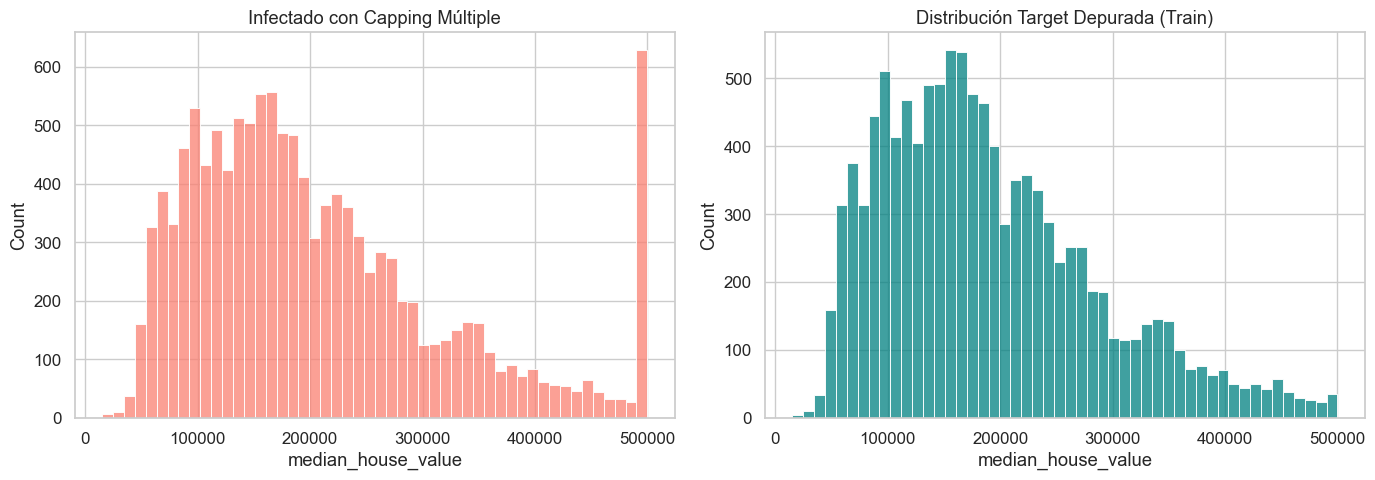

In [2]:
# Función incorporada en build_features.py
housing_uncapped = drop_capped_values(housing_train, is_train=True)

limpiados = len(housing_train) - len(housing_uncapped)
print(f"[-] Censuras eliminadas exitosamente: {limpiados} registros.")
print(f"[*] Dimensión Operativa Aislada: {len(housing_uncapped):,} distribuciones.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(housing_train['median_house_value'], bins=50, ax=axes[0], color='salmon')
axes[0].set_title('Infectado con Capping Múltiple')
sns.histplot(housing_uncapped['median_house_value'], bins=50, ax=axes[1], color='teal')
axes[1].set_title('Distribución Target Depurada (Train)')
plt.tight_layout()
plt.show()


---
## 2. Mitigación de Ausencia Estocástica (MCAR)

Diagnosticada la ausencia de impacto causal en los datos nulos (`total_bedrooms`), evadimos la pérdida territorial y aplicamos imputación mediánica transversal usando los parámetros formados netamente sobre esta capa aislada de Data Training (`housing_uncapped`).

In [3]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
housing_num = housing_uncapped.drop("ocean_proximity", axis=1)

# Calibraje exclusivo de paramétricos de Media en Train
imputer.fit(housing_num)
X_imputed = imputer.transform(housing_num)
housing_tr = pd.DataFrame(X_imputed, columns=housing_num.columns, index=housing_num.index)

print(f"[+] Total Nulos remanentes en Target Numérico: {housing_tr.isnull().sum().sum()}")


[+] Total Nulos remanentes en Target Numérico: 0


---
## 3. Disolución de Multicolinealidad Espacial (Ratios Derivados)

Las altas tasas de autocorrelación entre métricas poblacionales en crudo exigen descomponer la densidad censal usando nuestra clase programada `CombinedAttributesAdder`.

In [4]:
from src.features.build_features import CombinedAttributesAdder

# Extracción paramétrica 
attr_adder = CombinedAttributesAdder()
housing_features_added = attr_adder.transform(housing_tr)

nuevas_columnas = ['rooms_per_household', 'population_per_household', 'bedrooms_per_room']

print("Resumen de Coeficientes Modificados (Pearson):\n")
for col in nuevas_columnas:
    corr = housing_features_added[col].corr(housing_features_added['median_house_value'])
    print(f"  {col:<30} r = {corr:+.4f}")


Resumen de Coeficientes Modificados (Pearson):

  rooms_per_household            r = +0.1084
  population_per_household       r = -0.1430
  bedrooms_per_room              r = -0.2093


---
## 4. Normalización Logarítmica de Colas Computacionales Extensas (Skewness) 

Demostrado el severo sesgo en ingresos y tamaño demográfico (`Skewness > 4`), un pre-escalado de estándar simple distorsionaría el *Score*. Exigimos someter al set a derivación $log_{e}(1+x)$ para encauzar un comportamiento de campana.

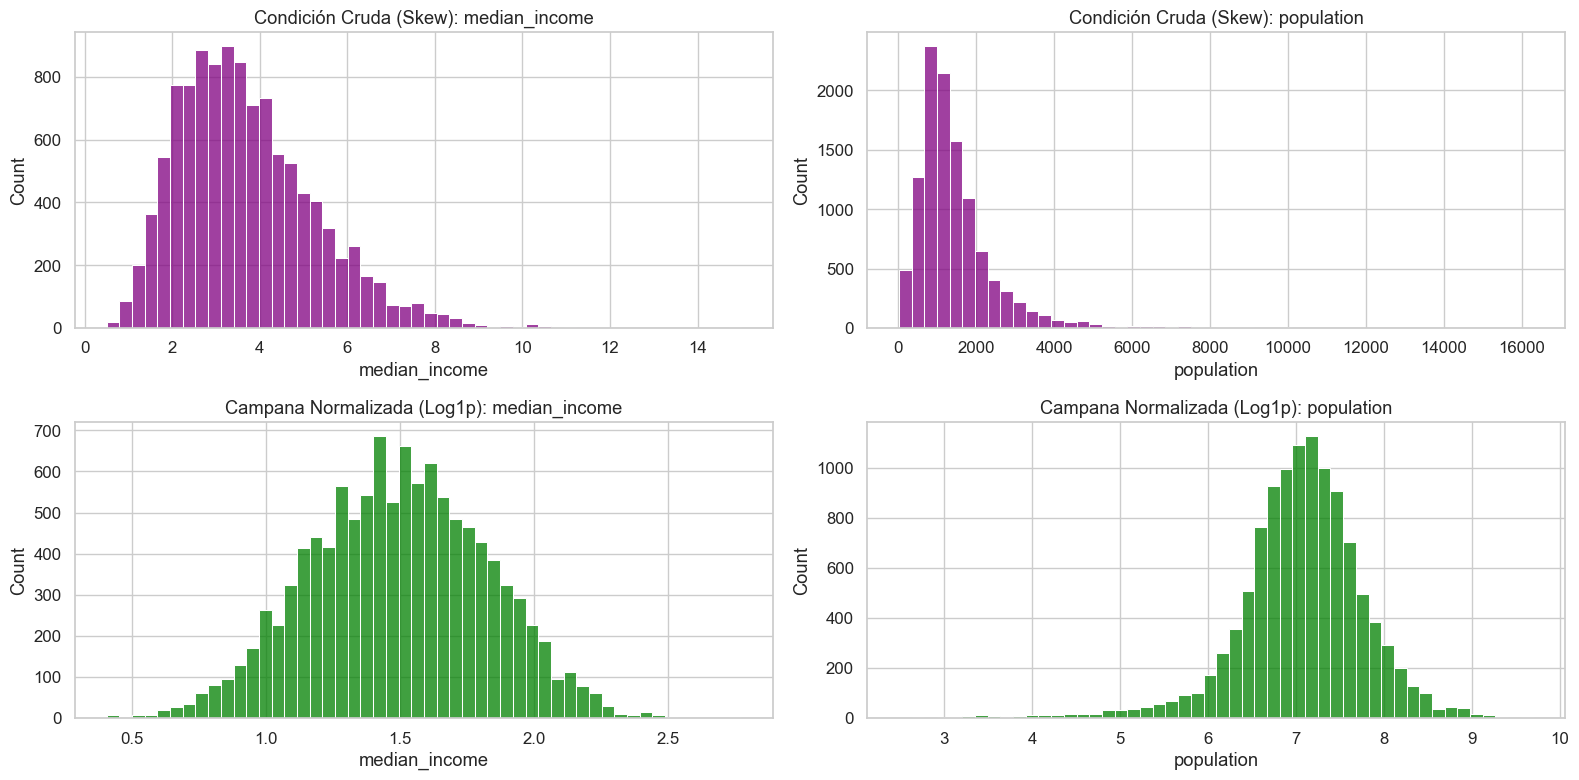

In [5]:
target_sk_features = ['median_income', 'population']

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
for i, col in enumerate(target_sk_features):
    # Condición Original de Asimetría
    sns.histplot(housing_features_added[col], bins=50, ax=axes[0, i], color='purple')
    axes[0, i].set_title(f'Condición Cruda (Skew): {col}')
    
    # Supresión de Skewness (Log1p Transformer Logic)
    log_serie = np.log1p(housing_features_added[col])
    sns.histplot(log_serie, bins=50, ax=axes[1, i], color='green')
    axes[1, i].set_title(f'Campana Normalizada (Log1p): {col}')

plt.tight_layout()
plt.show()


---
## 5. Arquitectura Dinámica: Pipeline Unificado para Inferencia

Toda exploración, imputación, logaritmización, y vectorizado de categorías geográficas (`OneHotEncoder`) han sido colapsados unificadamente en su Pipeline Definitivo, para replicación escalable hacia los modelos algoritmos de `Machine Learning`.

In [6]:
# Secuencia algorítmica completa 
target = housing_uncapped['median_house_value']
features = housing_uncapped.drop('median_house_value', axis=1)

pipeline_definitivo = get_preprocessing_pipeline()
matrices_entrenamiento = pipeline_definitivo.fit_transform(features)

print(f"[*] Perfil Input (Estructura Cruda): {features.shape[1]} tensores numéricos/categóricos")
print(f"[*] Perfil Output (Pipeline Procesado): {matrices_entrenamiento.shape[1]} tensores normalizados, libres de multicolinealidad estructural.")


[*] Perfil Input (Estructura Cruda): 9 tensores numéricos/categóricos
[*] Perfil Output (Pipeline Procesado): 16 tensores normalizados, libres de multicolinealidad estructural.
